In [1]:
#| include: false
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':130,'savefig.dpi':130,'font.size':10,'axes.titlesize':11})
BLUE,CORAL,TEAL,PURP,GREY='#3b8bd4','#d85a30','#1d9e75','#5a4aa0','#888888'


**Who this is for.** You have a strong programming background and solid linear algebra
and dynamical-systems math, but no prior graph-neural-network background. So standard
linear algebra is assumed; the GNN-specific ideas are built up from the ground.

**How it is organized.** Six modules in dependency order. Each concept comes with (a)
what it is, (b) why it exists, (c) the mechanism with notation, (d) a short intuition or
micro-example, and (e) how it connects to its neighbors. Sections end with one or two
self-check questions. Equations are the ones in the primary papers (see References);
where a formula's normalization varies by author, that is flagged.

**Scope notes (so you know what is deliberately in or out).**
- The spectral view (Module 2) is kept *compact*: just enough to explain where the GCN
  layer comes from and why deep GCNs act as low-pass filters. It is not a full
  graph-signal-processing survey.
- GraphSAGE neighbor *sampling* is taught as a concept because it underpins the
  large-graph discussion, but it is **not** exercised in a small full-batch Cora setup —
  there, all neighbors are used every step.
- t-SNE / UMAP and the micro-F1-equals-accuracy point are **out of scope here** (they are
  general-ML tooling, not GNN theory). The *idea* that oversmoothing shows up as visual
  cluster-collapse is kept, in Module 4.

Notation, fixed once: a graph $\mathcal{G}=(\mathcal{V},\mathcal{E})$ has $n=|\mathcal{V}|$
nodes; $A\in\mathbb{R}^{n\times n}$ is the adjacency matrix; $X\in\mathbb{R}^{n\times d}$
stacks the $d$-dimensional node feature vectors as rows; $H^{(l)}$ is the matrix of node
representations at layer $l$, with $H^{(0)}=X$.

## Module 0 — Framing: the task and the data

**(a) What.** The problem is *semi-supervised node classification* on a single graph. The
nodes are entities, the edges are relationships, each node carries a feature vector, and a
*small* subset of nodes is labeled. The goal is to predict the labels of the rest.

**(b) Why it exists.** In many domains the data is relational, not a flat table: papers
citing papers, users interacting with items, atoms bonded in a molecule. A plain
classifier on node features alone throws away the edges. A graph model uses both the
features *and* the wiring, so that label information can propagate along edges to the
unlabeled nodes.

**(c) Mechanism — the Cora benchmark.** Cora is a citation network: $n=2708$ machine-learning
papers (nodes), undirected citation links (edges, $\approx 5429$ of them). Each node has a
$1433$-dimensional **binary bag-of-words** feature vector $x_i\in\{0,1\}^{1433}$ (which
dictionary words appear in the paper), and one of **7** topic labels. The standard
*Planetoid* split (Yang et al., 2016) is deliberately label-scarce: **140** nodes for
training (20 per class), **500** for validation, **1000** for test. Training on 140 labels
to classify 1000 is what makes the task *semi-supervised* — the model must lean on graph
structure, not just labels.

**(d) Intuition.** "Semi-supervised" here does not mean unlabeled *examples* of a separate
test set. It is *transductive*: the whole graph, including the test nodes' features and
edges, is visible during training; only the test *labels* are hidden. You are filling in
missing labels on a graph you can see in full.

**(e) Connects to.** Everything downstream is a way to turn "use the features and the
wiring together" into a differentiable layer. Module 1 gives the algebra to write the
wiring down; Modules 2–3 turn it into a network.

> **Self-check.** Only 140 of 2708 nodes are labeled at training time, yet the test nodes'
> feature vectors and edges are available. Why does that make graph structure essential
> rather than optional?

## Module 1 — Graph algebra: the objects everything is built from

**(a) What.** A handful of matrices derived from $A$ that let neighborhood operations be
written as matrix multiplications.

**(b) Why it exists.** "Average each node with its neighbors" is a per-node, per-edge
description. To run it efficiently and differentiate through it, it must become a single
linear map applied to the feature matrix $X$. These matrices are that linear map.

**(c) Mechanism.**

- **Adjacency** $A$: $A_{ij}=1$ if there is an edge $i\!-\!j$, else $0$. Undirected $\Rightarrow$ $A$
  symmetric.
- **Degree** $D=\mathrm{diag}(d_1,\dots,d_n)$ with $d_i=\sum_j A_{ij}$ (how many neighbors
  node $i$ has).
- **Graph Laplacian** $L := D - A$. It is symmetric positive-semidefinite. Its quadratic
  form is the key identity of this whole tutorial:
$$
x^\top L\, x = \tfrac{1}{2}\sum_{(i,j)\in\mathcal{E}} (x_i - x_j)^2 .
$$
  So $x^\top L x$ measures how much a signal $x$ *disagrees across edges*. It is $0$ iff
  $x$ is constant on each connected component, and large when neighbors differ.
- **Normalized Laplacians** (two conventions): symmetric $L_{\mathrm{sym}} = D^{-1/2} L
  D^{-1/2}$ and random-walk $L_{\mathrm{rw}} = D^{-1} L$.
- **Self-loops and the renormalized adjacency.** Add a self-loop to every node:
  $\tilde A = A + I$, with $\tilde D = \mathrm{diag}(\sum_j \tilde A_{ij})$. Then the
  operator that the GCN will use is
$$
\hat A \;=\; \tilde D^{-1/2}\,\tilde A\,\tilde D^{-1/2}.
$$
  This is a *symmetric, degree-normalized averaging* matrix: row $i$ of $\hat A X$ is a
  weighted average of node $i$ and its neighbors, with weight $1/\sqrt{\tilde d_i \tilde d_j}$
  on the edge $i\!-\!j$.

**(d) Micro-example.** Path graph $1\!-\!2\!-\!3$. Then $A$ has ones on the $1\!-\!2$ and
$2\!-\!3$ edges, $D=\mathrm{diag}(1,2,1)$, and
$$
L = \begin{bmatrix} 1 & -1 & 0 \\ -1 & 2 & -1 \\ 0 & -1 & 1 \end{bmatrix}.
$$
For the signal $x=(0,0,4)^\top$: $x^\top L x = \tfrac12\big[(x_1-x_2)^2 + (x_2-x_3)^2\big]
= \tfrac12[0 + 16] = 8 > 0$ — the disagreement lives entirely on the $2\!-\!3$ edge,
exactly as the sum-over-edges formula says.

**(e) Connects to.** $\hat A$ is literally the GCN propagation operator (Module 2–3). The
Laplacian quadratic form $x^\top L x$ becomes the **Dirichlet energy** that measures
oversmoothing (Module 4). Learn this identity once; it reappears three times.

> **Self-check.** Without computing eigenvalues, argue why $x^\top L x \ge 0$ for every
> $x$, and describe every $x$ that makes it exactly $0$.

## Module 2 — Two views of graph convolution: spectral, then spatial

This module answers "why does the GCN layer look the way it does?" There are two lenses on
the same operation. The spectral lens explains the *origin*; the spatial lens is how you
actually think about and implement it.

### 2.1 The spectral view (compact)

**(a) What.** A graph convolution defined by transforming a signal into the Laplacian's
eigenbasis, reweighting each frequency, and transforming back.

**(b) Why it exists.** On a regular grid, convolution = multiplication in the Fourier
domain. Graphs have no grid, but $L_{\mathrm{sym}}$ plays the role of the Fourier basis:
its eigenvectors are "graph frequencies" (low frequency = smooth across edges, high
frequency = oscillating across edges). A *spectral filter* $g_\theta$ is a function applied
to the eigenvalues.

**(c) Mechanism, and the chain of approximations that yields GCN.** Directly using the
eigenbasis requires eigendecomposing $L_{\mathrm{sym}}$ ($\mathcal{O}(n^3)$) — impractical.
Defferrard et al. approximate $g_\theta$ by a truncated **Chebyshev polynomial**, which is
"spectrum-free" (no eigendecomposition, just powers of $L_{\mathrm{sym}}$):
$$
g_\theta \star s \;\approx\; \sum_{k=0}^{K} \theta'_k\, T_k(L_{\mathrm{sym}})\, s .
$$
Kipf & Welling then take the most drastic simplification: set $K=1$ and approximate
$\lambda_{\max}\!\approx\!2$, collapsing the filter to
$$
g_\theta \star s \;=\; \theta\left(I + D^{-1/2} A D^{-1/2}\right) s .
$$
The matrix $I + D^{-1/2}AD^{-1/2}$ has eigenvalues in $[0,2]$; stacking many such layers
would risk numerical blow-up/vanishing, so they apply the **renormalization trick**
$$
I + D^{-1/2} A D^{-1/2} \;\longrightarrow\; \tilde D^{-1/2}\tilde A \tilde D^{-1/2} = \hat A,
\qquad \tilde A = A + I .
$$
That $\hat A$ is exactly the averaging operator from Module 1.

**(d) Intuition.** Read the chain as a collapse from "arbitrary filter" to "one specific
low-pass filter." A $K=1$ polynomial in $L_{\mathrm{sym}}$ that emphasizes small
eigenvalues *keeps* the smooth (low-frequency) part of a signal and *attenuates* the
oscillating part. GCN is, spectrally, a fixed low-pass filter — remember this for Module 4,
where "low-pass, applied repeatedly" becomes the cause of oversmoothing.

**(e) Connects to.** The endpoint $\hat A$ is the spatial operator below. The
"fixed low-pass filter" reading is the seed of both oversmoothing (Module 4) and GCNII's
fix (Module 5), which restores *arbitrary* filter coefficients.

### 2.2 The spatial view (message passing) — the operational picture

**(a) What.** The same $\hat A X$ read node-by-node: each node's new representation is a
normalized average of itself and its neighbors, followed by a learned linear map and a
nonlinearity.

**(c) Mechanism — the GCN layer.** Generalizing $\hat A$ to feature matrices with a learned
weight $\Theta^{(l)}$ and activation $\sigma$:
$$
\boxed{\,H^{(l+1)} = \sigma\!\left(\hat A\, H^{(l)}\, \Theta^{(l)}\right)\,},
\qquad \hat A = \tilde D^{-1/2}\tilde A \tilde D^{-1/2}.
$$
Two-layer GCN for classification: $Z = \mathrm{softmax}\!\left(\hat A\,\mathrm{ReLU}(\hat A
X \Theta^{(0)})\,\Theta^{(1)}\right)$.

**(d) Why depth = reach.** One application of $\hat A$ mixes each node with its immediate
neighbors. Two applications ($\hat A^2$) mix in neighbors-of-neighbors. After $L$ layers, a
node's representation depends on its entire **$L$-hop neighborhood** — this is the
*receptive field*, and it is the reason depth is the central knob of the whole study.

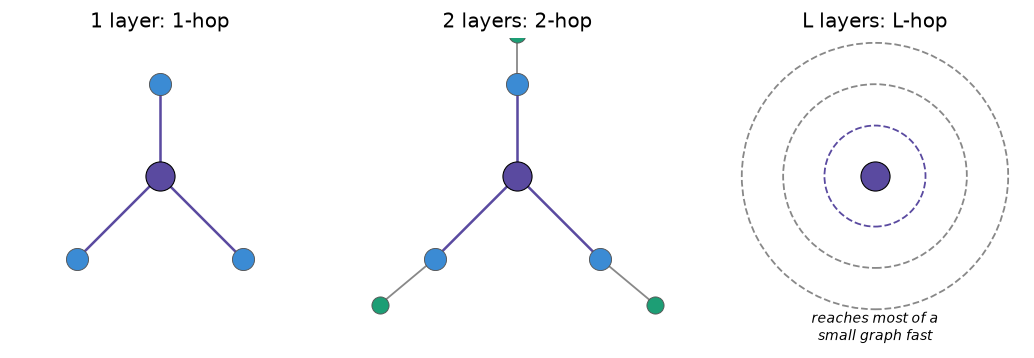

In [2]:
#| echo: false
#| label: fig-receptive
#| fig-cap: "Receptive field growth. On a small, tightly clustered graph like Cora this expands to cover most of the graph within a handful of layers — which is exactly why oversmoothing appears at shallow depth here."
fig,ax=plt.subplots(1,3,figsize=(8.4,2.7))
for a in ax: a.set_aspect('equal'); a.axis('off'); a.set_xlim(-1.6,1.6); a.set_ylim(-1.7,1.5)
def hub(a): a.scatter([0],[0],s=260,c=PURP,zorder=3,edgecolors='k',linewidths=0.6)
# panel 0: 1-hop
a=ax[0]; a.set_title('1 layer: 1-hop')
n1=[(-0.9,-0.9),(0.9,-0.9),(0,1.0)]
for x,y in n1: a.plot([0,x],[0,y],color=PURP,lw=1.4,zorder=1)
a.scatter([p[0] for p in n1],[p[1] for p in n1],s=150,c=BLUE,edgecolors='#555',linewidths=0.5,zorder=2); hub(a)
# panel 1: 2-hop
a=ax[1]; a.set_title('2 layers: 2-hop')
for x,y in n1: a.plot([0,x],[0,y],color=PURP,lw=1.4,zorder=1)
n2=[(-1.5,-1.4),(1.5,-1.4),(0,1.55)]
for (x1,y1),(x2,y2) in zip(n1,n2): a.plot([x1,x2],[y1,y2],color=GREY,lw=1.0,zorder=1)
a.scatter([p[0] for p in n2],[p[1] for p in n2],s=90,c=TEAL,edgecolors='#555',linewidths=0.5,zorder=2)
a.scatter([p[0] for p in n1],[p[1] for p in n1],s=150,c=BLUE,edgecolors='#555',linewidths=0.5,zorder=2); hub(a)
# panel 2: L-hop
a=ax[2]; a.set_title('L layers: L-hop')
for r in (0.55,1.0,1.45): a.add_patch(plt.Circle((0,0),r,fill=False,ls='--',ec=PURP if r<1 else GREY,lw=1.0))
hub(a); a.text(0,-1.65,'reaches most of a\nsmall graph fast',ha='center',va='center',fontsize=8,style='italic')
plt.tight_layout(); plt.show()


**(e) Connects to.** The spatial picture generalizes to a template (Module 3) that GCN,
GraphSAGE, and GAT all instantiate. The receptive-field idea is what makes "depth vs.
performance" the experimental axis.

> **Self-check.** Spectrally, GCN is a fixed low-pass filter. Predict, before reading
> Module 4, what repeatedly low-pass-filtering the node features must do to the *differences*
> between neighboring nodes as depth grows.

## Module 3 — Message passing and the three architectures

### 3.1 The message-passing template

**(a) What.** A two-step abstraction that every architecture here fits: **aggregate**
neighbor information, then **update** the node's own state.
$$
m_v^{(l)} = \mathrm{AGGREGATE}\big(\{\,h_u^{(l)} : u\in\mathcal{N}(v)\,\}\big),\qquad
h_v^{(l+1)} = \mathrm{UPDATE}\big(h_v^{(l)},\, m_v^{(l)}\big).
$$

**(b) Why it exists.** It separates two design choices — *how neighbors are combined* and
*how a node folds that in with its own state* — so architectures can be compared as
different fillings of the same template rather than as unrelated models.

**(e) Connects to.** GCN, GraphSAGE, and GAT differ **only** in how they weight and
combine neighbors. Keeping the template fixed makes the comparison in this study
apples-to-apples.

### 3.2 GCN — fixed, structure-determined averaging

Mechanism (from Module 2): $h_v^{(l+1)} = \sigma\big(\sum_{u\in\mathcal{N}(v)\cup\{v\}}
\tfrac{1}{\sqrt{\tilde d_v \tilde d_u}}\, \Theta^{(l)\top} h_u^{(l)}\big)$. The neighbor
weight $1/\sqrt{\tilde d_v \tilde d_u}$ is **fixed by the graph**: it depends only on
degrees, never on the features, and is the same every epoch. GCN treats all neighbors
symmetrically. Simple and strong, but it cannot decide a neighbor is irrelevant.

### 3.3 GraphSAGE — sample, and keep self separate from neighbors

**(a) What.** Aggregate a (possibly *sampled*) neighbor set, then **concatenate** the
result with the node's own previous state before the linear map — a deliberate
self/neighbor split.

**(c) Mechanism.**
$$
h_{\mathcal{N}(v)}^{(k)} = \mathrm{AGG}_k\big(\{h_u^{(k-1)} : u\in\mathcal{N}(v)\}\big),\qquad
h_v^{(k)} = \sigma\!\Big(W^{(k)} \cdot \mathrm{CONCAT}\big(h_v^{(k-1)},\, h_{\mathcal{N}(v)}^{(k)}\big)\Big),
$$
followed by L2 normalization $h_v^{(k)} \leftarrow h_v^{(k)}/\|h_v^{(k)}\|_2$. The
aggregator $\mathrm{AGG}$ can be **mean** ($\frac{1}{|\mathcal N(v)|}\sum_u h_u$),
**pooling** ($\max$ over $\sigma(Wh_u+b)$), or **LSTM** (over a random neighbor order).

**(d) Two ideas worth separating.**
1. *Self/neighbor separation* (the CONCAT): unlike GCN, which blends a node into the same
   average as its neighbors, SAGE keeps "who I am" and "what my neighborhood says" in
   distinct slots. This is the part that runs on Cora full-batch.
2. *Neighbor sampling*: fix a budget (say 25 neighbors) and sample that many per node per
   layer. This is what makes SAGE scale to graphs too large to hold in memory — the reach
   of the large-graph discussion. **On small full-batch Cora, sampling is typically off:
   all neighbors are used every step.** Sampling is in scope as a *concept*, not as
   something these particular runs exercise.

### 3.4 GAT — learn how much each neighbor matters

**(a) What.** Replace the fixed weight with an **attention** coefficient computed from the
two endpoints' features.

**(c) Mechanism.** Raw score, softmax-normalized over the neighborhood, then weighted sum:
$$
e_{ij} = \mathrm{LeakyReLU}\big(a^\top [\,W h_i \,\|\, W h_j\,]\big),\qquad
\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k\in\mathcal{N}_i}\exp(e_{ik})},\qquad
h_i' = \sigma\!\Big(\sum_{j\in\mathcal{N}_i}\alpha_{ij}\,W h_j\Big).
$$
**Multi-head:** run $K$ independent attentions in parallel; concatenate them in hidden
layers, average them at the output layer, to stabilize training.

**(d) The one-line contrast.** In GCN the neighbor weight is $1/\sqrt{\tilde d_i \tilde
d_j}$ — fixed by structure. In GAT it is $\alpha_{ij}$ — computed from features and learned.
If a neighbor's features are unhelpful, attention can down-weight it regardless of the
graph.

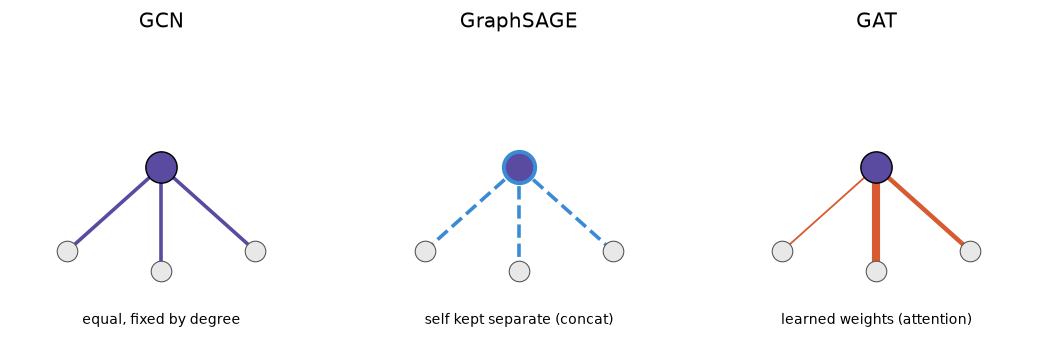

In [3]:
#| echo: false
#| label: fig-weighting
#| fig-cap: "Same template, three neighbor-weighting rules. Line thickness = weight."
fig,ax=plt.subplots(1,3,figsize=(8.4,2.7))
titles=['GCN','GraphSAGE','GAT']; subs=['equal, fixed by degree','self kept separate (concat)','learned weights (attention)']
nbr=[(-0.95,-0.85),(0,-1.05),(0.95,-0.85)]
lws=[[2,2,2],[2,2,2],[1.0,4.5,2.5]]
cols=[PURP,BLUE,CORAL]; styles=['-','--','-']
for k,a in enumerate(ax):
    a.set_aspect('equal'); a.axis('off'); a.set_xlim(-1.5,1.5); a.set_ylim(-1.7,1.3); a.set_title(titles[k])
    for (x,y),lw in zip(nbr,lws[k]): a.plot([0,x],[0,y],color=cols[k],lw=lw,ls=styles[k],zorder=1)
    a.scatter([p[0] for p in nbr],[p[1] for p in nbr],s=130,c='#e8e8e8',edgecolors='#555',linewidths=0.6,zorder=2)
    hubc = dict(s=300,c=PURP,edgecolors='k',linewidths=0.8,zorder=3)
    if k==1: hubc.update(edgecolors=BLUE,linewidths=2.2)   # highlight self for SAGE
    a.scatter([0],[0],**hubc)
    a.text(0,-1.55,subs[k],ha='center',va='center',fontsize=8)
plt.tight_layout(); plt.show()


> **Self-check.** All three fit the aggregate-then-update template. State, in one sentence
> each, what plays the role of the neighbor weight in GCN vs. GAT, and what GraphSAGE's
> CONCAT buys you that GCN's blended average does not.

## Module 4 — Oversmoothing: what collapses, why, and how to measure it

### 4.1 The phenomenon and its mechanism

**(a) What.** As depth grows, message-passing GNNs drive all node representations toward
each other until they become nearly indistinguishable — and accuracy collapses, because
nodes from different classes are no longer separable.

**(b) Why it happens (the mechanism, not just the symptom).** Li et al. (2018) show that
GCN's graph convolution is a special form of **Laplacian smoothing**: one layer replaces
each node's features with a weighted average of itself and its neighbors. That averaging is
*why shallow GCNs work* — it makes same-cluster nodes similar and eases classification. But
it is a contraction toward agreement across edges. Apply it over and over (deep network)
and the features converge to a fixed point that depends only on node degree, not on class:
within each connected component, everything blurs into the same vector. Spectrally
(Module 2), this is the same statement as "a low-pass filter applied many times kills every
component except the flattest one."

**(d) Why Cora feels it early.** Cora is small and tightly clustered, so the receptive
field covers most of the graph within a few layers (Module 2 figure). Collapse is
therefore fully visible well before extreme depth — which is why the sweep can stop at 32
layers and still show the whole story.

### 4.2 Measuring it — two diagnostics

You need scalar summaries of "how collapsed are the representations at layer $l$?" Two are
standard, and they are measured **per layer** so you can see *where* collapse begins.

**Dirichlet energy** — disagreement across edges. Reusing the Module 1 identity, for a
representation matrix $H$:
$$
E(H) \;=\; \mathrm{tr}\!\big(H^\top \hat L\, H\big) \;=\; \tfrac{1}{2}\sum_{(i,j)\in\mathcal{E}} \Big\| \tfrac{h_i}{\sqrt{1+d_i}} - \tfrac{h_j}{\sqrt{1+d_j}} \Big\|_2^2 ,
$$
where $\hat L = I - \hat A$ is the (self-loop) normalized Laplacian. It **falls toward
zero** as neighbors' representations converge. (Conventions differ: some authors use the
unnormalized $\tfrac12\sum_{(i,j)}\|h_i-h_j\|^2 = \mathrm{tr}(H^\top L H)$, and Zhao &
Akoglu track the closely related *total pairwise squared distance*. Pick one convention and
state it — the *trend*, not the absolute value, is what matters.)

**MAD (Mean Average Distance)** — global dissimilarity via cosine distance. With
$D_{ij} = 1 - \cos(h_i, h_j)$, MAD averages these pairwise cosine distances (Chen, Lin, Li,
Zhou & Sun, 2020). It **falls toward zero** as all representations point the same
direction. MAD ignores magnitude (it is angle-only), so it complements Dirichlet energy,
which is magnitude-sensitive; reporting both is more robust than either alone.

**(d) Sanity intuition.** Identical embeddings on every node $\Rightarrow$ every edge difference is
$0$ $\Rightarrow$ Dirichlet energy $=0$ and MAD $=0$. Random embeddings $\Rightarrow$ both clearly positive. Those
two limiting cases are exactly the correctness checks you'd run on an implementation.

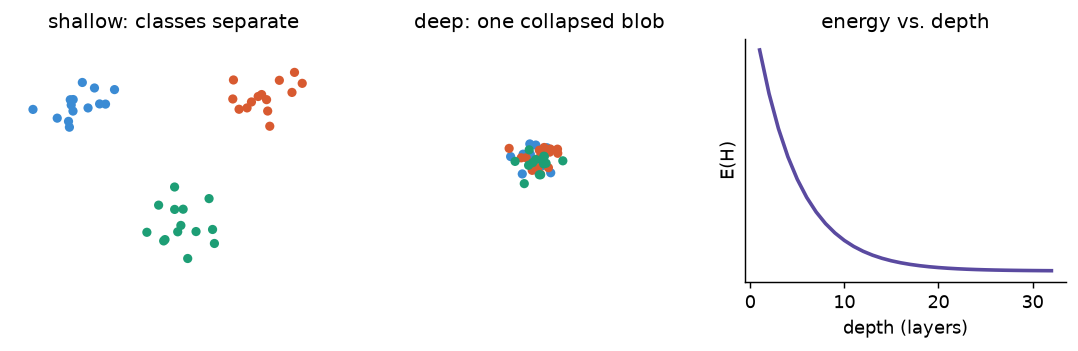

In [4]:
#| echo: false
#| label: fig-oversmoothing
#| fig-cap: "Left/middle: the cluster-collapse you'd see in a 2-D embedding plot at shallow vs. deep settings. Right: Dirichlet energy decaying toward zero with depth — the same collapse, as a number you can log per layer."
rng=np.random.default_rng(0)
fig,ax=plt.subplots(1,3,figsize=(8.4,2.8))
# separated clusters
cts=[(-1.1,0.9),(1.1,0.9),(0,-1.0)]; cols=[BLUE,CORAL,TEAL]
a=ax[0]; a.set_title('shallow: classes separate')
for c,col in zip(cts,cols):
    p=rng.normal(c,0.28,(14,2)); a.scatter(p[:,0],p[:,1],s=26,c=col,edgecolors='none')
a.set_xlim(-2,2); a.set_ylim(-2,2); a.axis('off')
# collapsed blob
a=ax[1]; a.set_title('deep: one collapsed blob')
for col in cols:
    p=rng.normal((0,0),0.16,(14,2)); a.scatter(p[:,0],p[:,1],s=26,c=col,edgecolors='none')
a.set_xlim(-2,2); a.set_ylim(-2,2); a.axis('off')
# energy decay
a=ax[2]; a.set_title('energy vs. depth')
d=np.arange(1,33); E=np.exp(-0.22*d)+0.01
a.plot(d,E,color=PURP,lw=2)
a.set_xlabel('depth (layers)'); a.set_ylabel('E(H)'); a.set_yticks([]); a.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


**(e) Connects to.** Everything in Module 5 is a modification that keeps $E(H)$ from
decaying to zero — either by re-injecting un-smoothed signal, by renormalizing distances,
or by mixing in shallow layers.

> **Self-check.** Dirichlet energy uses squared Euclidean edge-differences; MAD uses cosine
> distance and so ignores vector magnitude. Give one situation where the two could disagree
> about "how collapsed" the representations are.

## Module 5 — Mitigations: restoring performance at depth

All four share one goal: stop the representations from collapsing as layers stack. They
attack it from different angles.

### 5.1 Residual / skip connections

**(a) What.** Add the previous layer's representation back after the graph convolution:
$H^{(l+1)} = \sigma(\hat A H^{(l)}\Theta^{(l)}) + H^{(l)}$ (ResNet-style).

**(b/c) Why and mechanism.** A skip gives each node a path to retain its *own* prior state
rather than being fully overwritten by the neighborhood average, and it eases gradient flow
in deep stacks. **Honest caveat (Kipf & Welling; reiterated by GCNII):** a plain residual
only *partially* relieves oversmoothing — performance still degrades as you keep stacking.
It is the baseline mitigation, and the reason the stronger methods below exist.

### 5.2 PairNorm — hold total pairwise distance constant

**(a) What.** A normalization layer inserted after each graph convolution that forces the
*total pairwise squared distance* between node representations to stay constant across
depth, so they cannot all collapse together.

**(c) Mechanism (two steps: center, then scale).** With input $\tilde X$ (the layer's
pre-activation output) and output $\dot X$:
$$
\tilde x_i^{\,c} = \tilde x_i - \tfrac{1}{n}\sum_{i=1}^n \tilde x_i \quad\text{(Center)},
\qquad
\dot x_i = s\sqrt{n}\,\frac{\tilde x_i^{\,c}}{\|\tilde X^{c}\|_F} \quad\text{(Scale)} .
$$
This fixes the total pairwise squared distance at $2n^2 s^2$, where $s>0$ is a
hyperparameter. Oversmoothing wants to shrink all pairwise distances to zero; PairNorm
simply *renormalizes them back up* after every layer, so the average distance can't decay.

**(d) Intuition.** It doesn't stop *individual* pairs from moving; it stops the *whole
cloud* from imploding, by rescaling the cloud to a fixed spread every layer.

### 5.3 Jumping Knowledge (JK) — let the output pick its own depth

**(a) What.** Instead of using only the last layer, collect every layer's representation
$h_v^{(1)},\dots,h_v^{(L)}$ and combine them at the end — they all "jump" to the output.

**(c) Mechanism.** Layer-aggregation of the jumped representations by **concatenation**
$[h_v^{(1)},\dots,h_v^{(L)}]$ (then a linear map), element-wise **max-pooling**, or an
**LSTM-attention** over layers.

**(d) Why it helps.** Different nodes need different reach: a node in a dense region
oversmooths after few hops, one in a sparse region needs more. JK lets each node
effectively select the depth (the layer) at which its representation was most informative,
*before* collapse set in — an adaptive receptive field rather than a fixed one.

### 5.4 GCNII — initial residual + identity mapping

**(a) What.** The strongest of the four: two changes to the GCN layer that provably let a
$K$-layer network still express a $K$-order filter with **arbitrary** coefficients (recall
vanilla GCN is stuck with *fixed* coefficients — the Module 2 point — which is what forces
oversmoothing).

**(c) Mechanism.**
$$
H^{(\ell+1)} = \sigma\!\Big( \big((1-\alpha_\ell)\,\hat A\, H^{(\ell)} + \alpha_\ell\, H^{(0)}\big)\,\big((1-\beta_\ell)\, I_n + \beta_\ell\, W^{(\ell)}\big)\Big).
$$
Two devices:
1. **Initial residual** $\alpha_\ell H^{(0)}$: every layer mixes in a fraction of the
   *original input* $H^{(0)}$ — the least-smoothed signal there is. This guarantees the
   representation always retains at least an $\alpha_\ell$ share of the input, so it can
   never fully collapse. (Typically $\alpha_\ell = \alpha \approx 0.1$, constant.)
2. **Identity mapping** $(1-\beta_\ell)I_n + \beta_\ell W^{(\ell)}$: shrink the weight
   toward the identity as depth grows (typically $\beta_\ell = \log(1 + \lambda/\ell) \to
   0$). This keeps weight norms small (strong regularization, good for the label-scarce
   regime) and, following ResNet theory, keeps the only critical point the global minimum.

**(d) The through-line.** Notice GCN, GAT, and GCNII can all be written as one layer
$h_i^{(l+1)} = \sigma\big(\sum_{j}\big[(1-\alpha)c_{ij}h_j + \alpha h_j^{(0)}\big]\big[(1-\beta)+\beta\,\theta_{ij}\big]\big)$
with $c_{ij}=1/\sqrt{\tilde d_i\tilde d_j}$ (GCN) or $c_{ij}=\alpha_{ij}$ (GAT), and
$\alpha=\beta=0$ recovering the plain layer. GCNII is "the plain layer, plus keep a slice
of the input, plus lean the weights toward identity." Seeing them as one family is the
cleanest way to hold the whole module together.

> **Self-check.** Residual connections and GCNII's *initial* residual are not the same
> thing. What does a ResNet-style residual connect to, what does GCNII's initial residual
> connect to, and why does the latter resist collapse more effectively?

## References (verified against source)

Ordered by where they enter the tutorial. Two citations correct gaps in the project's
original list, flagged inline.

1. Sen, P., Namata, G., Bilgic, M., Getoor, L., Gallagher, B., & Eliassi-Rad, T. (2008).
   *Collective Classification in Network Data.* AI Magazine 29(3). — origin of the Cora
   dataset. *(M0)*
2. Yang, Z., Cohen, W. W., & Salakhutdinov, R. (2016). *Revisiting Semi-Supervised
   Learning with Graph Embeddings (Planetoid).* ICML. — the standard 140/500/1000 split.
   *(M0)*
3. Defferrard, M., Bresson, X., & Vandergheynst, P. (2016). *Convolutional Neural Networks
   on Graphs with Fast Localized Spectral Filtering (ChebNet).* NeurIPS. — the Chebyshev
   spectral filter GCN simplifies from. *Not in the original proposal list; cited here
   only for the compact spectral derivation in M2.* *(M2)*
4. Kipf, T. N., & Welling, M. (2017). *Semi-Supervised Classification with Graph
   Convolutional Networks.* ICLR (arXiv 1609.02907). — GCN; the $K{=}1$ simplification and
   renormalization trick. *(M2, M3)*
5. Hamilton, W. L., Ying, R., & Leskovec, J. (2017). *Inductive Representation Learning on
   Large Graphs (GraphSAGE).* NeurIPS. — sample + aggregate + concat. *(M3)*
6. Veličković, P., Cucurull, G., Casanova, A., Romero, A., Liò, P., & Bengio, Y. (2018).
   *Graph Attention Networks.* ICLR (arXiv 1710.10903). — attention weighting. *(M3)*
7. Li, Q., Han, Z., & Wu, X.-M. (2018). *Deeper Insights into Graph Convolutional Networks
   for Semi-Supervised Learning.* AAAI (arXiv 1801.07606). — GCN as Laplacian smoothing;
   the oversmoothing mechanism. *(M4)*
8. Chen, D., Lin, Y., Li, W., Li, P., Zhou, J., & Sun, X. (2020). *Measuring and Relieving
   the Over-Smoothing Problem for Graph Neural Networks from the Topological View.* AAAI
   (arXiv 1909.03211). — **origin of MAD.** *This is a different "Chen 2020" from the GCNII
   paper below and was uncited in the proposal; added here.* *(M4)*
9. Cai, C., & Wang, Y. (2020). *A Note on Over-Smoothing for Graph Neural Networks.* arXiv
   2006.13318. — Dirichlet-energy formulation used in M4. *Added here to source a quantity
   the proposal named but did not cite.* *(M4)*
10. Zhao, L., & Akoglu, L. (2020). *PairNorm: Tackling Oversmoothing in GNNs.* ICLR (arXiv
    1909.12223). — center-and-scale normalization; total pairwise squared distance. *(M5)*
11. Xu, K., Li, C., Tian, Y., Sonobe, T., Kawarabayashi, K., & Jegelka, S. (2018).
    *Representation Learning on Graphs with Jumping Knowledge Networks.* ICML (arXiv
    1806.03536). — layer-aggregation. *(M5)*
12. Chen, M., Wei, Z., Huang, Z., Ding, B., & Li, Y. (2020). *Simple and Deep Graph
    Convolutional Networks (GCNII).* ICML (arXiv 2007.02133). — initial residual + identity
    mapping. *(M5)*
13. He, K., Zhang, X., Ren, S., & Sun, J. (2016). *Deep Residual Learning for Image
    Recognition.* CVPR. — the ResNet residual/identity-mapping idea reused in M5. *(M5)*